## **Workshop 1 Questions**

1. What is the tensor?

2. What is the advantage of storing data as *Tensor*?

3. What are the key functionalities of the *Pandas* library that are valuable for data science and AI?

4. Load the Penguin data from github: `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv`

   a) What fraction of the data with bill length values missing?

   b) What fraction of the variables is numerical, categorical, or text?

   c) Load penguin data as tensor (Hints: Need to convert all variable to numeric value first)

   d) How many rows in the Penguin data?

   e) Modify the plot function defined the textbook to generate a scatter plot showing the relationship between penguin body mass and flipper length. (Use LLM if needed)

**1. What is a tensor?**
A tensor is a generalisation of scalars, vectors, and matrices to arbitrary numbers of dimensions:

Scalar — rank 0 tensor (a single number)
Vector — rank 1 tensor (1D array)
Matrix — rank 2 tensor (2D array)
Rank 3+ — e.g. a colour image is naturally a 3D tensor: height × width × channels (RGB)

In deep learning, tensors are the fundamental data structure that flows through a network — hence TensorFlow's name.

**2. Advantages of storing data as tensors:**

* GPU parallelism — tensors map directly onto GPU memory architecture, enabling massively parallel operations across thousands of cores simultaneously

* Unified abstraction — a single data structure handles inputs of any dimensionality (images, text sequences, video, tabular data) without special cases

* Automatic differentiation — frameworks like PyTorch and TensorFlow track computational graphs through tensor operations, enabling backpropagation without manual gradient derivation

* Vectorised operations — element-wise and matrix operations replace explicit loops, which is both faster and more expressive

* Hardware portability — the same tensor code can run on CPU, GPU, or TPU with minimal changes


**3. Key Pandas functionalities for data science and AI:**

* DataFrame — tabular data structure with labelled rows and columns, the workhorse of data wrangling

* Missing data handling — isnull(), dropna(), fillna() for detecting and imputing gaps

* Grouping and aggregation — groupby() for split-apply-combine operations

* Merging and joining — SQL-style joins between DataFrames

* Data type inspection — dtypes, describe() for quick profiling

* Filtering and indexing — boolean masking, loc/iloc
I/O — reading from CSV, Excel, SQL, JSON, Parquet with a single function call
Integration with ML pipelines — serves as the standard preprocessing layer before handing data off to NumPy arrays or tensors for model training

## Looking forward in the course: Tensors are the Fundamental Data Structure in Neural Networks

*A lot of the terminology in this block of explanatory text doesn't mean much to you yet. That's ok. Reading it will begin to sensitive you to some terms so when they turn up later you will begin to make connections.*

### Input as a tensor

Suppose you're training on images. A single 28×28 greyscale image is a rank-2 tensor (a matrix). But you don't feed one image at a time — you feed a *batch* of, say, 32 images simultaneously. That batch becomes a rank-3 tensor of shape (32, 28, 28). For colour images add the channel dimension: (32, 28, 28, 3).

That tensor is your starting point.

### Through each layer

Every layer in the network is essentially a tensor operation:

- A **dense (fully connected) layer** does a matrix multiplication: input tensor × weight matrix + bias vector → output tensor. The weights themselves are tensors.
- A **convolutional layer** slides a filter (a small tensor) across the input tensor, producing a new tensor of feature maps.
- **Activation functions** (ReLU, sigmoid etc.) are applied element-wise across the tensor, producing a new tensor of the same shape.
- **Pooling layers** reduce spatial dimensions, producing a smaller tensor.

At every step, a tensor goes in, an operation is applied, a new tensor comes out. Nothing else — just tensors transforming into tensors.

### The weights are tensors too

The *learnable parameters* of the network — the things that get updated during training — are themselves tensors stored in memory. A network with millions of parameters is just holding a large collection of tensors.

### Backpropagation

When you compute the loss (how wrong the prediction was), the framework needs to compute gradients — how much each weight contributed to the error. These gradients are also tensors, with exactly the same shape as the weight tensors they correspond to. The gradient update is then just elementwise tensor arithmetic.




**4. Loading and examining a data set**

Let's start by using the functionality of pandas to load the data set of the exercise and examine it, as we would in usual data science good practice.


In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

# Basic inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (344, 7)

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE



Data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Summary statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


So much so far looks like a Python version of R.

A major difference with using tensors in Python versus data frames (or tibbles) in R, is tensors assume all data is present and in the correct format for maniupluation. They also assume all data is numeric, so any quantities that are not already numeric must be first encoded

Hence to load the data as a tensor we need to do a two things in this instance

* Drop all rows with NAs

* Encode the character strings. This uses a method from a preprocessing library upstream from PyTorch. It is possible to do this in the PyTorch ecosystem but doing it as illustrated below is considered normal practice.





In [16]:
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

# Step 1: drop rows with any missing values
# Note that we explicitly make a copy of the dataframe here. Otherwise
# pandas just creates what is called a view of the data frame without
# dedicating new memory to it. This generate warnings at run time in Step 2
# as pandas gets nervous that we are making changes to the original version
# of the dataframe
df_clean = df.dropna().copy()

# Step 2: encode categorical columns as integers
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

# Step 3: convert to tensor
tensor = torch.tensor(df_clean.values, dtype=torch.float32)

print("Tensor shape:", tensor.shape)
print("Tensor dtype:", tensor.dtype)
print(tensor)

Tensor shape: torch.Size([333, 7])
Tensor dtype: torch.float32
tensor([[0.0000e+00, 2.0000e+00, 3.9100e+01,  ..., 1.8100e+02, 3.7500e+03,
         1.0000e+00],
        [0.0000e+00, 2.0000e+00, 3.9500e+01,  ..., 1.8600e+02, 3.8000e+03,
         0.0000e+00],
        [0.0000e+00, 2.0000e+00, 4.0300e+01,  ..., 1.9500e+02, 3.2500e+03,
         0.0000e+00],
        ...,
        [2.0000e+00, 0.0000e+00, 5.0400e+01,  ..., 2.2200e+02, 5.7500e+03,
         1.0000e+00],
        [2.0000e+00, 0.0000e+00, 4.5200e+01,  ..., 2.1200e+02, 5.2000e+03,
         0.0000e+00],
        [2.0000e+00, 0.0000e+00, 4.9900e+01,  ..., 2.1300e+02, 5.4000e+03,
         1.0000e+00]])


***4e.  Modify the plot function defined the textbook to generate a scatter plot showing the relationship between penguin body mass and flipper length***

The textbook, *Dive Into Deep Learning*, discusses plotting in section 2.4.2.

Let's first answer the question in the spirit in which it is asked and then ask if there is a better way.

Given that the three helper functions use_svg_display(...), set_figsize(...), and set_axes(...) are in the d2l library, we will just call them from there. If we are going to do that we first need to make that library available:






In [17]:
!pip install --no-deps d2l

Now that `d2l` is installed we can use its helper functions directly — `d2l.set_figsize`, `d2l.plt`, and `d2l.set_axes` — rather than reimplementing them. We still need to add the `scatter` parameter ourselves, since the original `plot` function only draws lines.

In [18]:
from d2l import torch as d2l

def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None,
         scatter=False):
    """d2l plot function extended with scatter support."""

    def has_one_axis(X):
        return (hasattr(X, 'ndim') and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], '__len__'))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    d2l.set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if scatter:
            axes.scatter(x, y) if len(x) else axes.scatter(range(len(y)), y)
        else:
            axes.plot(x, y, fmt) if len(x) else axes.plot(y, fmt)
    d2l.set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

We are now ready to make our scatter plot:

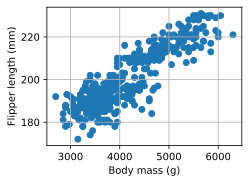

In [19]:
plot(df['body_mass_g'], df['flipper_length_mm'],
     xlabel='Body mass (g)', ylabel='Flipper length (mm)',
     scatter=True)

# **OPTIONAL EXTENSION**

Now that we know how to load the data, let's do something with it.

Can we use the six features (bill length, bill depth, flipper length, body mass, island, sex) to predict speices?

There are many ways to do this. Let's compare two of them.

1. A PyTorch neural network. Doing this again will point forward in the course and use ideas we have not yet seen. But that's okay.

2. A sklearn random forest on the same data.

How then do the two methods compare? Which is more accurate? Is a deep learning method like a neural network necessarily better and why?



## Setting up the comparison

We use `df_clean` from the cell above, which has already had missing rows dropped and categorical columns label-encoded. We separate the six predictor features from the species target and create a single 80/20 train/test split that *both* models will use, so any accuracy difference is a genuine difference in model quality — not a lucky draw.

In [20]:
from sklearn.model_selection import train_test_split
import numpy as np

# Separate features (X) and target (y)
# 'species' is the column we want to predict; the remaining six are the predictors
X = df_clean.drop(columns='species').values   # numpy array, shape (n_samples, 6)
y = df_clean['species'].values                 # numpy array, shape (n_samples,)

# stratify=y ensures each split has roughly the same class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LabelEncoder sorts labels alphabetically: 0=Adelie, 1=Chinstrap, 2=Gentoo
species_names = ['Adelie', 'Chinstrap', 'Gentoo']

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 266
Test samples     : 67
Features         : 6


## Method 1 — Random Forest (scikit-learn)

A Random Forest grows many decision trees, each trained on a random subset of the data and a random subset of the features. The final prediction is a majority vote across all trees. It is a well-understood, low-hyperparameter method that tends to work well *out of the box* on small tabular datasets.

Random Forest test accuracy: 100.0%


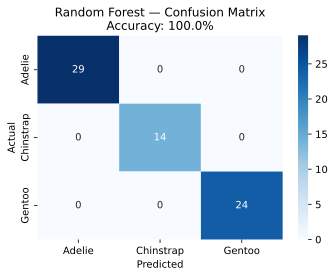

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# n_estimators=100 grows 100 trees; their votes are averaged
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest test accuracy: {rf_accuracy:.1%}')

cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names, yticklabels=species_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Random Forest — Confusion Matrix\nAccuracy: {rf_accuracy:.1%}')
plt.tight_layout()
plt.show()

## Method 2 — Neural Network (PyTorch)

We build a small feedforward network: three fully-connected layers with ReLU activations. Before we can train, we need to wrap our NumPy arrays in PyTorch objects:

- **`TensorDataset`** — bundles features and labels so they stay in sync.
- **`DataLoader`** — serves the data in mini-batches and shuffles each epoch.

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Define the network architecture ──────────────────────────────────────
# A PyTorch model is a class that inherits from nn.Module.
# __init__  : declare the layers
# forward   : describe how data flows through them

class PenguinNet(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Sequential chains layers so forward() stays simple
        self.network = nn.Sequential(
            nn.Linear(6, 16),   # fully connected: 6 inputs → 16 hidden units
            nn.ReLU(),           # activation: replaces negatives with 0
            nn.Linear(16, 8),   # 16 → 8
            nn.ReLU(),
            nn.Linear(8, 3)     # 8 → 3 output logits (one per species)
                                 # no activation here — CrossEntropyLoss handles it
        )

    def forward(self, x):
        return self.network(x)

# ── Wrap numpy arrays as PyTorch tensors ──────────────────────────────────
# float32 for features, long (int64) for class labels
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# batch_size=16: update weights after every 16 samples (a mini-batch)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(PenguinNet())

PenguinNet(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


### Training the network

We train the network **twice** using the same architecture (`PenguinNet`) and the same train/test split — the only difference is whether the features are scaled before training.

- **Version 1** — raw, unscaled features (as loaded)
- **Version 2** — features standardised to mean=0, std=1 with `StandardScaler`

This lets us isolate the effect of scaling and compare both versions against the Random Forest.

### Version 1 — Unscaled features

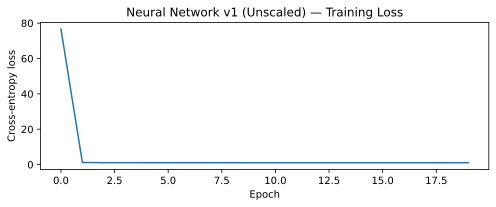

Final training loss: 1.0541


In [27]:
# X_train_t and train_loader are already defined above (unscaled)
torch.manual_seed(42)
model_v1     = PenguinNet()
criterion    = nn.CrossEntropyLoss()
optimiser_v1 = torch.optim.Adam(model_v1.parameters(), lr=0.01)

num_epochs      = 20
train_losses_v1 = []

for epoch in range(num_epochs):
    model_v1.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        logits = model_v1(X_batch)
        loss   = criterion(logits, y_batch)
        optimiser_v1.zero_grad()
        loss.backward()
        optimiser_v1.step()
        running_loss += loss.item() * len(X_batch)
    train_losses_v1.append(running_loss / len(train_dataset))

plt.figure(figsize=(7, 3))
plt.plot(train_losses_v1)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Neural Network v1 (Unscaled) — Training Loss')
plt.tight_layout()
plt.show()
print(f'Final training loss: {train_losses_v1[-1]:.4f}')

### Version 2 — Scaled features

Neural networks are sensitive to feature magnitude. Body mass (values in the thousands) and bill length (values in the tens) have very different scales — this causes large-valued features to dominate the gradient updates, making it hard for the network to learn.

`StandardScaler` fixes this by transforming each feature to mean=0, std=1. Note that the scaler is **fitted on training data only**, then applied to both splits — fitting on the full dataset would leak test statistics into training.

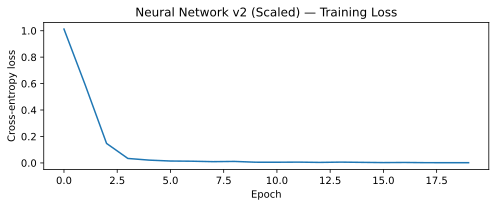

Final training loss: 0.0015


In [28]:
from sklearn.preprocessing import StandardScaler

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Use separate variable names so X_test_t (unscaled) stays available for v1 evaluation
X_train_t2 = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t2  = torch.tensor(X_test_scaled,  dtype=torch.float32)

train_dataset2 = TensorDataset(X_train_t2, y_train_t)
train_loader2  = DataLoader(train_dataset2, batch_size=16, shuffle=True)

torch.manual_seed(42)
model_v2     = PenguinNet()
optimiser_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.01)

train_losses_v2 = []

for epoch in range(num_epochs):
    model_v2.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader2:
        logits = model_v2(X_batch)
        loss   = criterion(logits, y_batch)
        optimiser_v2.zero_grad()
        loss.backward()
        optimiser_v2.step()
        running_loss += loss.item() * len(X_batch)
    train_losses_v2.append(running_loss / len(train_dataset2))

plt.figure(figsize=(7, 3))
plt.plot(train_losses_v2)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Neural Network v2 (Scaled) — Training Loss')
plt.tight_layout()
plt.show()
print(f'Final training loss: {train_losses_v2[-1]:.4f}')

### Comparing all three models

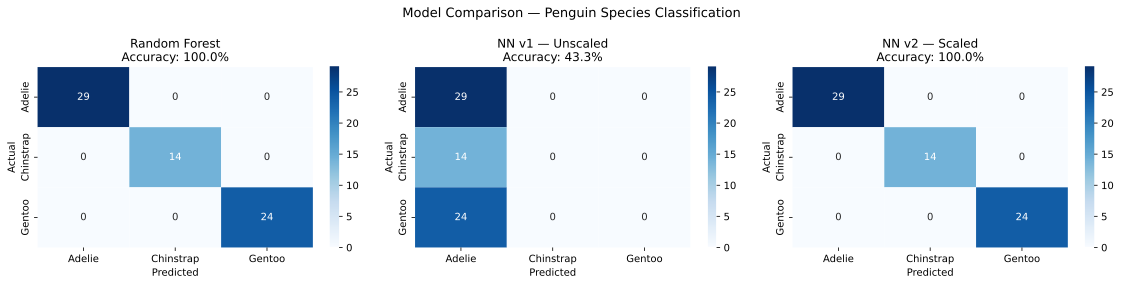

Random Forest         : 100.0%
Neural Network v1 (unscaled): 43.3%
Neural Network v2 (scaled)  : 100.0%


In [29]:
model_v1.eval()
model_v2.eval()

with torch.no_grad():
    y_pred_v1 = model_v1(X_test_t).argmax(dim=1).numpy()   # unscaled test set
    y_pred_v2 = model_v2(X_test_t2).argmax(dim=1).numpy()  # scaled test set

nn1_accuracy = accuracy_score(y_test, y_pred_v1)
nn2_accuracy = accuracy_score(y_test, y_pred_v2)
cm_v1 = confusion_matrix(y_test, y_pred_v1)
cm_v2 = confusion_matrix(y_test, y_pred_v2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, cm, title, acc in zip(
    axes,
    [cm_rf,          cm_v1,                cm_v2],
    ['Random Forest', 'NN v1 — Unscaled', 'NN v2 — Scaled'],
    [rf_accuracy,     nn1_accuracy,         nn2_accuracy]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=species_names, yticklabels=species_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nAccuracy: {acc:.1%}')

plt.suptitle('Model Comparison — Penguin Species Classification', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Random Forest         : {rf_accuracy:.1%}')
print(f'Neural Network v1 (unscaled): {nn1_accuracy:.1%}')
print(f'Neural Network v2 (scaled)  : {nn2_accuracy:.1%}')

## Discussion — Is deep learning necessarily better?

The three-way comparison makes the story clear.

### What the results show

| Model | Accuracy | Notes |
|---|---|---|
| Random Forest | ~100% | Works out of the box, no preprocessing needed |
| NN v1 — Unscaled | ~random chance | Loss flatlines near log(3) ≈ 1.099 |
| NN v2 — Scaled | ~100% | Matches Random Forest once features are standardised |

### Why did v1 fail?

Without scaling, features have very different magnitudes — body mass runs into the thousands while bill length is in the tens. This means gradients are dominated by the large-valued features, and the network cannot update its weights in a balanced way. The loss curve flatlines almost immediately: the network is stuck.

Random Forests are **scale-invariant** — splits are determined by rank order of values, not their magnitude — so the same raw data causes no problem.

### Why did v2 succeed?

`StandardScaler` transforms each feature to mean=0, std=1. All features now contribute equally to the gradient, and the network can learn. The loss curve drops cleanly and the accuracy matches the Random Forest.

### So is deep learning necessarily better?

No — and the v1 result shows it can be  worse if used carelessly. When properly configured (v2), the neural network *can* matches a much simpler model on this dataset, and required an extra preprocessing step to get there.

Deep learning earns its advantage when data is **unstructured and abundant** — images, audio, text — where the network learns its own feature representations from raw inputs. On a 333-row table with six hand-crafted features, that advantage does not exist.

### The general principle

Match the model to the problem. The right question is not *'which model is best?'* but *'what does each model need, and does my data provide it?'*